# Unified Perceptual Autoencoder with MIM (V2 Improvements)
This notebook provides a complete environment to train and evaluate the ConvAutoencoder with:
- **Grayscale Processing** (to ignore lighting noise)
- **Increased Bottleneck Capacity** (64 channels at 16x16)
- **ELU** for smoother reconstruction gradients
- **Multi-Scale SSIM + L1 Loss**
- Dynamic Masked Image Modeling (MIM)
- Perceptual Loss (ResNet-18)
- Smart Model Caching with Mina's Empirical Thresholding



## 1. Setup & Imports


In [1]:
import os
import json
import hashlib
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image, ImageFilter
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix, roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt
import cv2

# Hardcode path for the notebook execution
if "notebooks/shared" in os.getcwd():
    os.chdir("../..")
print(f"Working Directory: {os.getcwd()}")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

DATA_ROOT = Path("data/raw/mvtec_ad")
if not DATA_ROOT.exists():
    DATA_ROOT = Path("../../data/raw/mvtec_ad")
SIZE = 256
BATCH_SIZE = 16
EPOCHS = 100


Working Directory: /home/benni/Documents/antigravity_workspace/industrial-component-anomaly-detection
Using device: cuda


## 2. Dynamic Augmentations & Object-Aware Masking (MIM)


In [2]:
def get_manifest(data_root):
    from app.domain.data import build_mvtec_manifest
    return build_mvtec_manifest(str(data_root))

def build_fair_evaluation_split(manifest, category, seed=42):
    from app.domain.data import build_fair_evaluation_split as build_split
    return build_split(manifest, category=category, seed=seed)

def apply_mim_mask(img_tensor, mask_tensor):
    corrupted_img = img_tensor.clone()
    mask_expanded = mask_tensor.expand_as(corrupted_img)
    corrupted_img[mask_expanded] = 0.5 
    return corrupted_img

def generate_random_patch_mask(size, patch_size=32, num_patches=5, object_mask=None):
    mask = torch.zeros(1, size, size, dtype=torch.bool)
    if object_mask is None:
        return mask
        
    obj_indices = torch.nonzero(object_mask.squeeze())
    if len(obj_indices) == 0:
        return mask
        
    for _ in range(num_patches):
        idx = torch.randint(0, len(obj_indices), (1,))
        y_center, x_center = obj_indices[idx][0]
        
        y1 = max(0, y_center - patch_size // 2)
        y2 = min(size, y_center + patch_size // 2)
        x1 = max(0, x_center - patch_size // 2)
        x2 = min(size, x_center + patch_size // 2)
        
        mask[:, y1:y2, x1:x2] = True
        
    mask = mask & object_mask
    return mask

class MVTecDataset(Dataset):
    def __init__(self, img_paths, category, is_train=True, use_mim=False):
        self.img_paths = img_paths
        self.category = category
        self.is_train = is_train
        self.use_mim = use_mim
        
        self.transform = transforms.Compose([
            transforms.Resize((SIZE, SIZE)),
            transforms.ToTensor(),
        ])
        
    def __len__(self):
        return len(self.img_paths)
        
    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        img = Image.open(img_path).convert('RGB')
        
        # Object separation using Otsu + Canny (from Mina's approach)
        gray = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2GRAY)
        gray_blurred = cv2.GaussianBlur(gray, (7, 7), 0)
        _, thresh = cv2.threshold(gray_blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
        edges = cv2.Canny(gray_blurred, 50, 150)
        combined = cv2.bitwise_or(thresh, edges)
        
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
        closed = cv2.morphologyEx(combined, cv2.MORPH_CLOSE, kernel)
        dilated = cv2.dilate(closed, kernel, iterations=2)
        
        object_mask = torch.tensor(cv2.resize(dilated, (SIZE, SIZE))) > 127
        object_mask = object_mask.unsqueeze(0)
        
        # Convert to Grayscale for training/evaluation
        img_gray = img.convert('L')
        clean_tensor = self.transform(img_gray)
        
        mask_tensor = torch.zeros(1, SIZE, SIZE, dtype=torch.bool)
        if self.is_train and self.use_mim:
            mask_tensor = generate_random_patch_mask(SIZE, patch_size=32, num_patches=6, object_mask=object_mask)
            
        if self.is_train and self.use_mim:
            corrupted_tensor = apply_mim_mask(clean_tensor, mask_tensor)
        else:
            corrupted_tensor = clean_tensor
            
        return corrupted_tensor, clean_tensor, object_mask

def load_category_paths(category):
    cat_dir = DATA_ROOT / category
    if not cat_dir.exists():
        raise FileNotFoundError(f"Category {category} not found at {cat_dir}")
        
    try:
        manifest = get_manifest(DATA_ROOT)
        split = build_fair_evaluation_split(manifest, category, seed=42)
        train_good = [Path(p) for p in split.fit_paths]
        val_good = [Path(p) for p in split.val_paths]
    except Exception:
        train_good_all = sorted((cat_dir / "train" / "good").glob("*.png"))
        np.random.seed(42)
        shuffled = np.random.permutation(train_good_all)
        split_idx = int(len(shuffled) * 0.85)
        train_good, val_good = list(shuffled[:split_idx]), list(shuffled[split_idx:])
    
    test_good = sorted((cat_dir / "test" / "good").glob("*.png"))
    test_defect, test_defect_masks = [], []
    test_dir = cat_dir / "test"
    if test_dir.exists():
        for defect_dir in sorted(test_dir.iterdir()):
            if not defect_dir.is_dir() or defect_dir.name == "good":
                continue
            for img_path in sorted(defect_dir.glob("*.png")):
                mask_path = cat_dir / "ground_truth" / defect_dir.name / f"{img_path.stem}_mask.png"
                test_defect.append(img_path)
                test_defect_masks.append(mask_path)

    return train_good, val_good, test_good, test_defect, test_defect_masks


## 3. Architecture & Tri-Fold Loss (Perceptual)


In [3]:
class ConvAutoencoder(nn.Module):
    def __init__(self, in_channels=1, bottleneck_channels=64):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=4, stride=2, padding=1), nn.BatchNorm2d(32), nn.ELU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1), nn.BatchNorm2d(64), nn.ELU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), nn.BatchNorm2d(128), nn.ELU(),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1), nn.BatchNorm2d(256), nn.ELU(),
            nn.Conv2d(256, bottleneck_channels, kernel_size=3, stride=1, padding=1)
        )
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(bottleneck_channels, 256, kernel_size=3, stride=1, padding=1), nn.BatchNorm2d(256), nn.ELU(),
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1), nn.BatchNorm2d(128), nn.ELU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1), nn.BatchNorm2d(64), nn.ELU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1), nn.BatchNorm2d(32), nn.ELU(),
            nn.ConvTranspose2d(32, in_channels, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.dec(self.enc(x))

class PerceptualLossModule(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1).eval()
        for param in resnet.parameters():
            param.requires_grad = False
            
        self.layer1 = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool, resnet.layer1)
        self.layer2 = nn.Sequential(self.layer1, resnet.layer2)
        self.normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        
    def forward(self, y_true, y_pred):
        # ResNet expects 3 channels. If grayscale, repeat channels.
        if y_true.size(1) == 1:
            y_true = y_true.repeat(1, 3, 1, 1)
            y_pred = y_pred.repeat(1, 3, 1, 1)
            
        y_true_norm = self.normalize(y_true)
        y_pred_norm = self.normalize(y_pred)
        return (F.mse_loss(self.layer1(y_pred_norm), self.layer1(y_true_norm)) + 
                F.mse_loss(self.layer2(y_pred_norm), self.layer2(y_true_norm))) * 0.5

def ssim_loss_single_scale(x, y, window_size):
    C1 = 0.01 ** 2
    C2 = 0.03 ** 2
    mu1 = F.avg_pool2d(x, window_size, stride=1, padding=window_size//2)
    mu2 = F.avg_pool2d(y, window_size, stride=1, padding=window_size//2)
    sigma1_sq = F.avg_pool2d(x * x, window_size, stride=1, padding=window_size//2) - mu1 ** 2
    sigma2_sq = F.avg_pool2d(y * y, window_size, stride=1, padding=window_size//2) - mu2 ** 2
    sigma12 = F.avg_pool2d(x * y, window_size, stride=1, padding=window_size//2) - mu1 * mu2
    ssim_map = ((2 * mu1 * mu2 + C1) * (2 * sigma12 + C2)) / ((mu1 ** 2 + mu2 ** 2 + C1) * (sigma1_sq + sigma2_sq + C2))
    return 1 - ssim_map.mean()

def ms_ssim_loss(x, y):
    # Multi-Scale SSIM at different window sizes
    loss = 0
    for w in [3, 7, 11]:
        loss += ssim_loss_single_scale(x, y, w)
    return loss / 3.0

def combined_loss_fn(recon, orig, perceptual_module, use_perceptual=True):
    loss_l1 = F.l1_loss(recon, orig)
    loss_ssim = ms_ssim_loss(recon, orig)
    loss = loss_l1 + loss_ssim
    if use_perceptual and perceptual_module is not None:
        loss += 0.5 * perceptual_module(orig, recon)
    return loss


## 4. Callbacks, Caching & Training Loop


In [4]:
class EarlyStoppingAndCheckpoint:
    def __init__(self, patience=5, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float('inf')
        self.counter = 0
        self.best_state_dict = None
        self.early_stop = False
        
    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.best_state_dict = model.state_dict().copy()
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

def train_autoencoder(category, use_perceptual=False, use_mim=False):
    # Deterministic Caching
    config = {
        "category": category,
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "use_perceptual": use_perceptual,
        "use_mim": use_mim,
        "channels": 1,
        "bottleneck": 64
    }
    config_hash = hashlib.sha256(json.dumps(config, sort_keys=True).encode()).hexdigest()[:12]
    model_dir = Path("data/models/pytorch_perceptual_ae")
    model_dir.mkdir(parents=True, exist_ok=True)
    model_path = model_dir / f"{category}_{config_hash}.pth"
    
    model = ConvAutoencoder(in_channels=1, bottleneck_channels=64).to(DEVICE)
    if model_path.exists():
        print(f"Loading cached model from {model_path}")
        model.load_state_dict(torch.load(model_path, map_location=DEVICE))
        return model
        
    print(f"Training new model...")
    train_g, val_g, _, _, _ = load_category_paths(category)
    train_ds = MVTecDataset(train_g, category, is_train=True, use_mim=use_mim)
    val_ds = MVTecDataset(val_g, category, is_train=False, use_mim=False)
    
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)
    
    perceptual_module = PerceptualLossModule().to(DEVICE) if use_perceptual else None
    callbacks = EarlyStoppingAndCheckpoint(patience=7)
    
    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0.0
        for corrupted_x, clean_x, mask in train_loader:
            corrupted_x, clean_x, mask = corrupted_x.to(DEVICE), clean_x.to(DEVICE), mask.to(DEVICE)
            
            optimizer.zero_grad()
            recon = model(corrupted_x)
            
            recon_masked = recon * mask
            clean_masked = clean_x * mask
            
            loss = combined_loss_fn(recon_masked, clean_masked, perceptual_module, use_perceptual)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * corrupted_x.size(0)
            
        train_loss /= len(train_ds)
        
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for corrupted_x, clean_x, mask in val_loader:
                corrupted_x, clean_x, mask = corrupted_x.to(DEVICE), clean_x.to(DEVICE), mask.to(DEVICE)
                recon = model(corrupted_x)
                
                recon_masked = recon * mask
                clean_masked = clean_x * mask
                loss = combined_loss_fn(recon_masked, clean_masked, perceptual_module, use_perceptual)
                val_loss += loss.item() * corrupted_x.size(0)
                
        val_loss /= len(val_ds)
        
        print(f"Epoch {epoch+1:02d}/{EPOCHS} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f}")
        
        scheduler.step(val_loss)
        callbacks(val_loss, model)
        if callbacks.early_stop:
            print("Early Stopping Triggered!")
            break
            
        torch.cuda.empty_cache()
            
    model.load_state_dict(callbacks.best_state_dict)
    torch.save(model.state_dict(), model_path)
    print(f"Training Complete. Saved model to {model_path}")
    return model


## 5. Strict Evaluation & Visualizations


In [5]:
def evaluate_model_strict(model, category):
    model.eval()
    _, val_good, test_good, test_defect, test_defect_masks = load_category_paths(category)
    
    if not test_defect:
        return
        
    print(f"\n--- Evaluation for {category} ---")
    
    # =========================================================================
    # 1. Validation Pass: Compute ae_threshold (Image-level 99th percentile)
    # =========================================================================
    val_ds = MVTecDataset(val_good, category, is_train=False)
    val_image_scores = []
    with torch.no_grad():
        for corrupted_x, clean_x, mask in val_ds:
            x = corrupted_x.unsqueeze(0).to(DEVICE)
            recon = model(x)
            
            orig_np = clean_x.permute(1, 2, 0).cpu().numpy()
            recon_np = recon.squeeze(0).permute(1, 2, 0).cpu().numpy()
            
            # Pixel-wise MAE on foreground object
            anomaly_map = np.mean(np.abs(orig_np - recon_np), axis=-1)
            anomaly_map = anomaly_map * mask.squeeze().numpy()
            
            val_image_scores.append(np.max(anomaly_map))
            
    ae_threshold = np.percentile(val_image_scores, 99.0)
    print(f"99th Percentile Validation Image Threshold: {ae_threshold:.5f}")
    
    # =========================================================================
    # 2. Test Pass
    # =========================================================================
    all_test_paths = test_good + test_defect
    y_true_image = [0] * len(test_good) + [1] * len(test_defect)
    test_ds = MVTecDataset(all_test_paths, category, is_train=False)
    
    anomaly_maps = []
    ground_truth_masks = []
    image_scores = []
    original_images = []
    reconstructed_images = []
    
    with torch.no_grad():
        for i, (corrupted_x, clean_x, mask) in enumerate(test_ds):
            x = corrupted_x.unsqueeze(0).to(DEVICE)
            recon = model(x)
            
            orig_np = clean_x.permute(1, 2, 0).cpu().numpy()
            recon_np = recon.squeeze(0).permute(1, 2, 0).cpu().numpy()
            
            # Pixel-wise error smoothed slightly to reduce noise
            error_map = np.mean(np.abs(orig_np - recon_np), axis=-1)
            error_map = cv2.GaussianBlur(error_map, (7,7), 0)
            
            anomaly_map = error_map * mask.squeeze().numpy()
            anomaly_maps.append(anomaly_map)
            image_scores.append(np.max(anomaly_map))
            
            # Convert single channel back to 3 for plotting nicely
            orig_disp = np.repeat(orig_np, 3, axis=-1)
            recon_disp = np.repeat(recon_np, 3, axis=-1)
            original_images.append(orig_disp)
            reconstructed_images.append(recon_disp)
            
            if i >= len(test_good):
                mask_path = test_defect_masks[i - len(test_good)]
                if mask_path.exists():
                    gt = np.array(Image.open(mask_path).resize((SIZE, SIZE))) > 0
                else:
                    gt = np.zeros((SIZE, SIZE))
                ground_truth_masks.append(gt)
            else:
                ground_truth_masks.append(np.zeros((SIZE, SIZE)))
                
    anomaly_maps = torch.tensor(np.stack(anomaly_maps))
    ground_truth_masks = torch.tensor(np.stack(ground_truth_masks), dtype=torch.int32)
    y_true_image = np.array(y_true_image)
    image_scores = np.array(image_scores)
    
    # =========================================================================
    # 3. Metrics (AUROC, F1, AUPIMO, HER)
    # =========================================================================
    img_auroc = roc_auc_score(y_true_image, image_scores)
    print(f"Image AUROC: {img_auroc:.4f}")
    
    y_pred_image = (image_scores > ae_threshold).astype(int)
    cm = confusion_matrix(y_true_image, y_pred_image)
    f1 = f1_score(y_true_image, y_pred_image)
    print(f"F1 Score at ae_threshold: {f1:.4f}")
    print(f"Confusion Matrix (TN, FP, FN, TP): {cm.ravel()}")
    
    # --- Spatial localization hit-rate (HER) ---
    hits = []
    top_k_fraction = 0.01
    for i in range(len(anomaly_maps)):
        if y_true_image[i] == 0:
            continue
        e_map = anomaly_maps[i].flatten().numpy()
        mask_flat = ground_truth_masks[i].flatten().numpy()
        if mask_flat.sum() == 0:
            continue
        k = max(1, int(len(e_map) * top_k_fraction))
        top_indices = np.argpartition(e_map, -k)[-k:]
        hits.append(mask_flat[top_indices].sum() / mask_flat.sum())
    hit_rate = np.mean(hits) if hits else 0.0
    print(f"Top-1% Defect Capture (HER): {hit_rate:.4f}")
    
    try:
        from anomalib.metrics import AUPIMO
        from anomalib.data import ImageBatch
        # Convert single-channel anomaly maps to match Anomalib expectations if needed, but 2D is fine.
        dummy_img = torch.zeros(len(anomaly_maps), 3, SIZE, SIZE, dtype=torch.float32)
        batch = ImageBatch(image=dummy_img, anomaly_map=anomaly_maps, gt_mask=ground_truth_masks.bool())
        
        aupimo_metric = AUPIMO(num_thresholds=50000, fpr_bounds=(1e-5, 1e-4))
        aupimo_metric.update(batch)
        result = aupimo_metric.compute()
        if hasattr(result, "aupimo_scores"):
            score = float(result.aupimo_scores.nanmean().item())
        elif isinstance(result, tuple) and len(result) > 1:
            score = float(result[1].nanmean().item())
        elif isinstance(result, dict):
            score = float(next(iter(result.values())))
        else:
            score = float(result)
        print(f"AUPIMO: {score:.4f}")
    except Exception as e:
        print(f"AUPIMO Calculation Failed (Check Anomalib setup): {e}")

    # =========================================================================
    # 4. Curves & Diagrams (Image & Pixel Level)
    # =========================================================================
    # --- Image Level Diagrams ---
    print("\n--- Image Level Diagrams ---")
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    precision, recall, pr_thresholds = precision_recall_curve(y_true_image, image_scores)
    pr_auc = auc(recall, precision)
    
    axes[0].plot(recall, precision, label=f"Image PR (AUC={pr_auc:.3f})")
    axes[0].set_xlabel("Recall")
    axes[0].set_ylabel("Precision")
    axes[0].set_title("Classical Precision-Recall Curve")
    axes[0].legend()
    
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
    axes[1].plot(pr_thresholds, precision[:-1], label="Precision")
    axes[1].plot(pr_thresholds, recall[:-1], label="Recall")
    axes[1].plot(pr_thresholds, f1_scores[:-1], label="F1 Score", linestyle="--")
    axes[1].axvline(ae_threshold, color="r", linestyle=":", label="99th Val Image Threshold")
    axes[1].set_xlabel("Threshold")
    axes[1].set_title("Precision/Recall vs. Threshold")
    axes[1].legend()
    plt.tight_layout()
    plt.show()
    
    # --- Pixel Level Diagrams ---
    print("\n--- Pixel Level Diagrams ---")
    flat_masks = ground_truth_masks.numpy().flatten()
    flat_scores = anomaly_maps.numpy().flatten()
    subsample_idx = np.random.choice(len(flat_masks), size=min(len(flat_masks), 200000), replace=False)
    pix_prec, pix_rec, pix_thresh = precision_recall_curve(flat_masks[subsample_idx], flat_scores[subsample_idx])
    pix_pr_auc = auc(pix_rec, pix_prec)
    pix_f1 = 2 * (pix_prec * pix_rec) / (pix_prec + pix_rec + 1e-8)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(pix_rec, pix_prec, label=f"Pixel PR (AUC={pix_pr_auc:.3f})")
    if 'score' in locals():
        axes[0].fill_between(pix_rec, 0, pix_prec, alpha=0.2, label=f"AUPIMO Area ~ {score:.3f}")
    axes[0].set_xlabel("Recall")
    axes[0].set_ylabel("Precision")
    axes[0].set_title("Classical Precision-Recall Curve (Pixel-Level)")
    axes[0].legend()
    
    axes[1].plot(pix_thresh, pix_prec[:-1], label="Precision")
    axes[1].plot(pix_thresh, pix_rec[:-1], label="Recall")
    axes[1].plot(pix_thresh, pix_f1[:-1], label="F1 Score", linestyle="--")
    
    best_f1_idx = np.argmax(pix_f1[:-1])
    best_thresh = pix_thresh[best_f1_idx]
    axes[1].axvline(best_thresh, color="g", linestyle=":", label=f"Max F1 Threshold: {best_thresh:.3f}")
    axes[1].set_xlabel("Threshold")
    axes[1].set_title("Precision/Recall vs. Threshold (Pixel-Level)")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

    # =========================================================================
    # 5. Visual Examples (Original vs Reconstruction vs Heatmap)
    # =========================================================================
    indices = [0] # 1st normal image
    num_anomalies = 3
    anom_indices = [i for i, y in enumerate(y_true_image) if y == 1]
    if len(anom_indices) > 0:
        indices.extend(anom_indices[:num_anomalies])
        
    for idx in indices:
        fig, axes = plt.subplots(1, 5, figsize=(20, 4))
        orig = original_images[idx]
        recon = reconstructed_images[idx]
        gt = ground_truth_masks[idx].numpy()
        hm = anomaly_maps[idx].numpy()
        pred_mask = (hm > ae_threshold).astype(int)
        
        axes[0].imshow(orig, cmap='gray')
        axes[0].set_title(f"Input (Label: {y_true_image[idx]})")
        axes[1].imshow(recon, cmap='gray')
        axes[1].set_title("Reconstruction")
        axes[2].imshow(gt, cmap='gray')
        axes[2].set_title("Ground Truth Mask")
        im = axes[3].imshow(hm, cmap='jet')
        axes[3].set_title("Error Heatmap")
        plt.colorbar(im, ax=axes[3], fraction=0.046, pad=0.04)
        axes[4].imshow(pred_mask, cmap='gray')
        axes[4].set_title("Predicted Mask")
        
        for ax in axes:
            ax.axis('off')
        plt.show()
        
    return model


## 6. Ablation Study



############################################################
=== RUN 4 (Advanced: YES MIM, YES Perceptual) ===
############################################################
Training new model...
[2026-09-15 22:00:50] [INFO] Building manifest for MVTec dataset at data/raw/mvtec_ad
[2026-09-15 22:00:51] [INFO] Built manifest: 5354 images across 15 categories


/home/benni/Documents/antigravity_workspace/industrial-component-anomaly-detection/.pixi/envs/dev/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 01/100 - Train Loss: 0.1877 - Val Loss: 0.1789
Epoch 02/100 - Train Loss: 0.1258 - Val Loss: 0.1173
Epoch 03/100 - Train Loss: 0.1091 - Val Loss: 0.1042
Epoch 04/100 - Train Loss: 0.0983 - Val Loss: 0.0943
Epoch 05/100 - Train Loss: 0.0944 - Val Loss: 0.0923
Epoch 06/100 - Train Loss: 0.0930 - Val Loss: 0.0913
Epoch 07/100 - Train Loss: 0.0921 - Val Loss: 0.0908
Epoch 08/100 - Train Loss: 0.0920 - Val Loss: 0.0899
Epoch 09/100 - Train Loss: 0.0907 - Val Loss: 0.0897
Epoch 10/100 - Train Loss: 0.0897 - Val Loss: 0.0897
Epoch 11/100 - Train Loss: 0.0881 - Val Loss: 0.0859
Epoch 12/100 - Train Loss: 0.0864 - Val Loss: 0.0855
Epoch 13/100 - Train Loss: 0.0850 - Val Loss: 0.0831
Epoch 14/100 - Train Loss: 0.0829 - Val Loss: 0.0782
Epoch 15/100 - Train Loss: 0.0795 - Val Loss: 0.0778
Epoch 16/100 - Train Loss: 0.0769 - Val Loss: 0.0732
Epoch 17/100 - Train Loss: 0.0752 - Val Loss: 0.0710
Epoch 18/100 - Train Loss: 0.0726 - Val Loss: 0.0687
Epoch 19/100 - Train Loss: 0.0708 - Val Loss: 

Metric `AUPIMO` will save all targets and predictions in buffer. For large datasets this may lead to large memory footprint.


AUPIMO: 0.1023


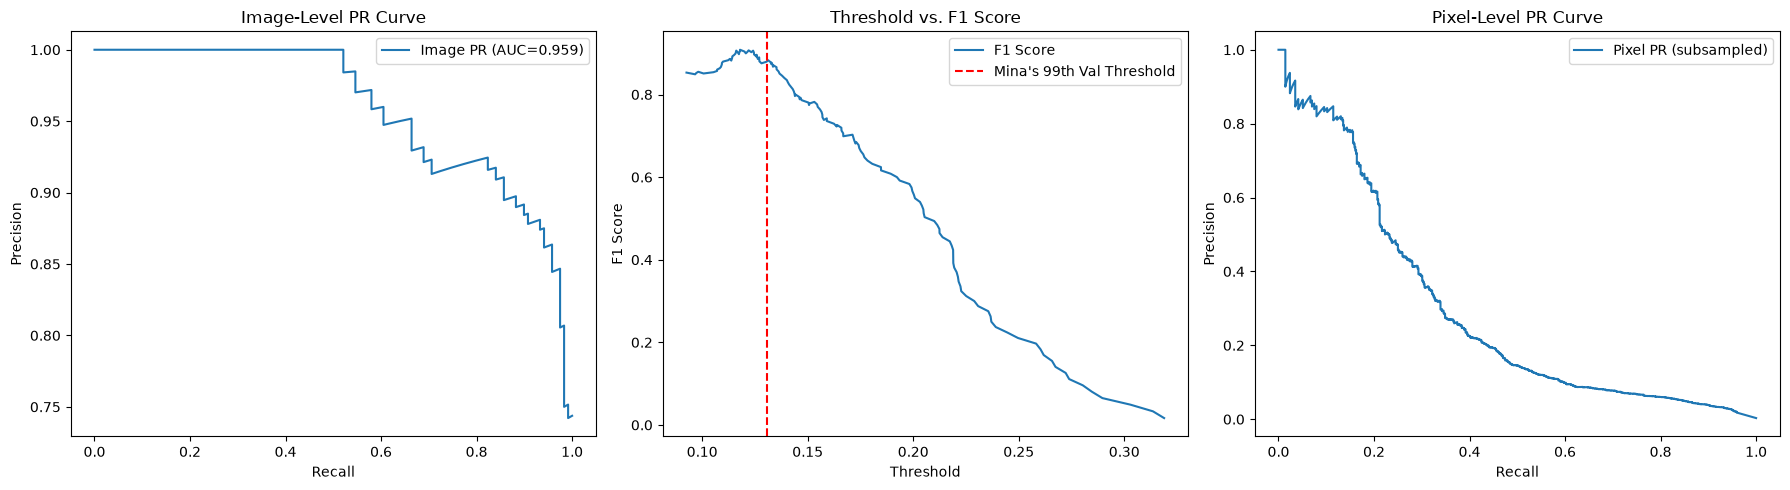

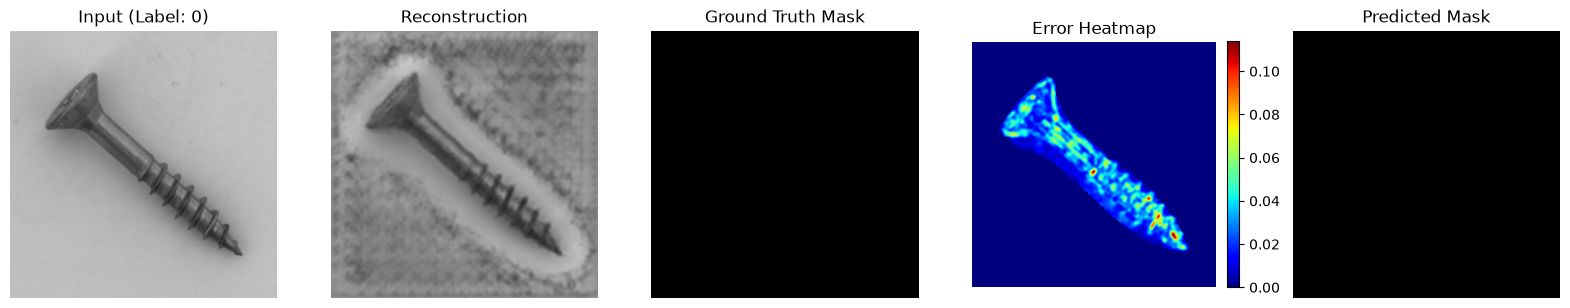

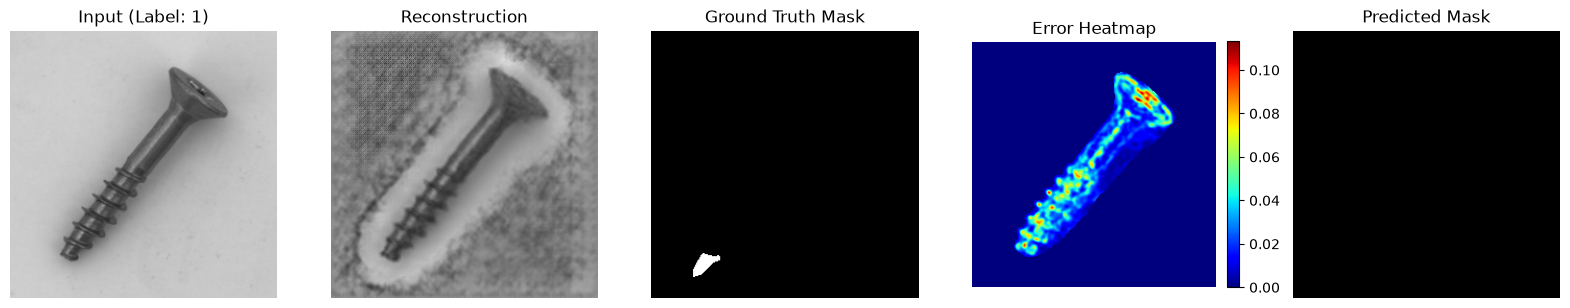

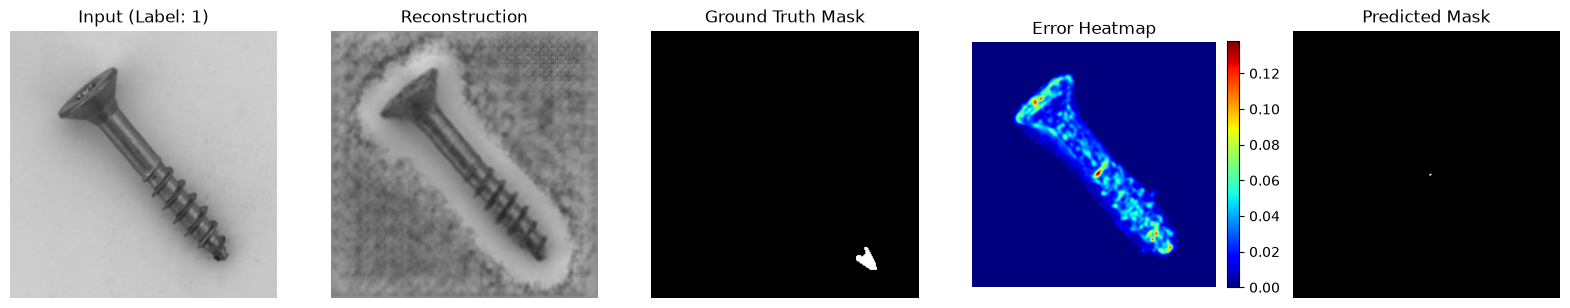

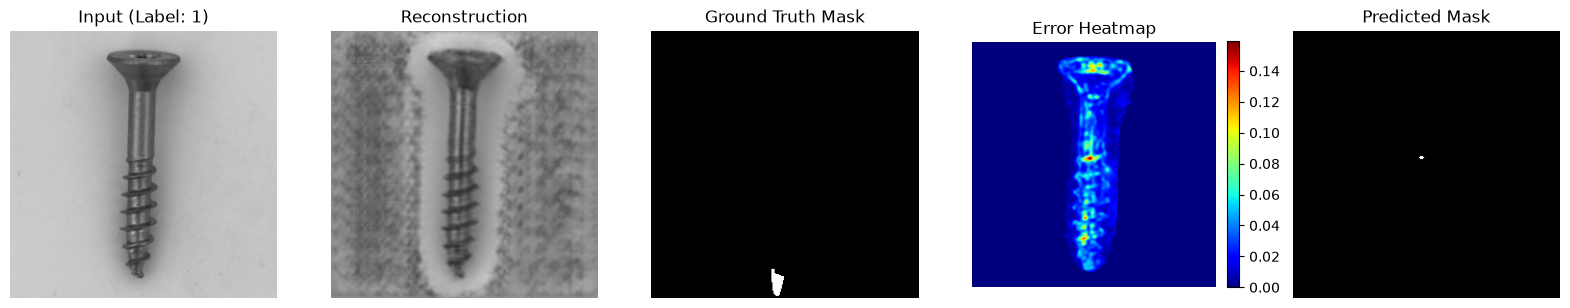

In [ ]:

scenarios = [
    # {"name": "RUN 1 (Baseline: No MIM, No Perceptual)", "use_mim": False, "use_perceptual": False},
    {"name": "RUN 2 (Loss Test: No MIM, YES Perceptual)", "use_mim": False, "use_perceptual": True},
    # {"name": "RUN 3 (MIM Test: YES MIM, No Perceptual)", "use_mim": True, "use_perceptual": False},
    # {"name": "RUN 4 (Advanced: YES MIM, YES Perceptual)", "use_mim": True, "use_perceptual": True},
]

for scenario in scenarios:
    print(f"\n{'#'*60}")
    print(f"=== {scenario['name']} ===")
    print(f"{'#'*60}")
    
    model = train_autoencoder(
        "screw", 
        use_perceptual=scenario["use_perceptual"], 
        use_mim=scenario["use_mim"]
    )
    
    if model:
        evaluate_model_strict(model, "screw")
